<a href="https://colab.research.google.com/github/Ferhadaghayev/Titanic-Dataset/blob/main/Titanic_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

df = pd.read_csv("/content/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [12]:
df.describe() #Numeric göstəricilər-Numeric indicators

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [250]:
df.isnull().sum() #NULL dəyərlər -- NULL values

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [240]:
df = df.dropna(subset=['age','deck']) #Age və deck sütunundakı NAN və NULL dəyərləri silirik --Deleting NAN and NULL values ​​in the Age and Deck columns
df
df.dropna(subset=['age','deck'])

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,AgeGroup
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,young adult
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True,adult
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,child
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False,adult
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True,young adult
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False,adult
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,young adult


/tmp/ipython-input-2984810523.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['Survived']).plot.bar()  #0-ölən insanlar,1-xilas olan insanlar ---- 0-people who died, 1-people who survived


<Axes: xlabel='Survived'>

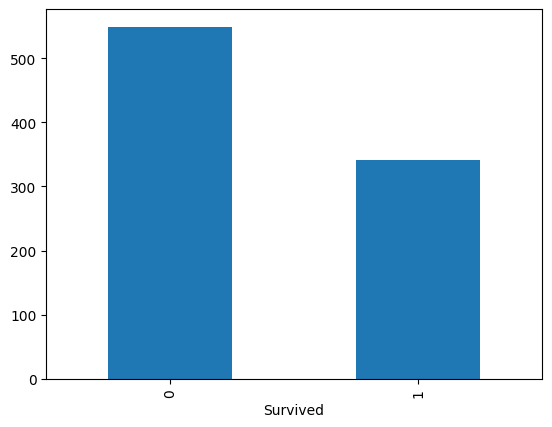

In [19]:
pd.value_counts(df['Survived']).plot.bar()  #0-ölən insanlar,1-xilas olan insanlar ---- 0-people who died, 1-people who survived

In [318]:
df['survived'].mean()*100  #Sərnişinlərin sağ qalma faizi -- Passenger survival rate

np.float64(67.93478260869566)

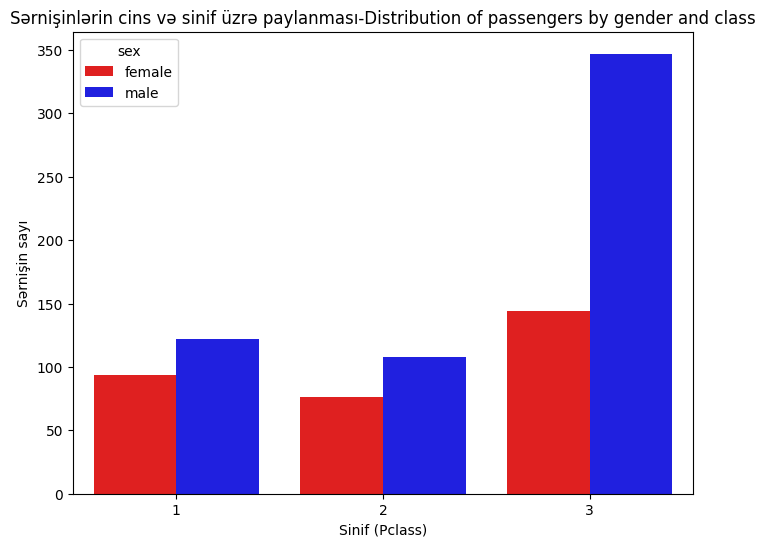

In [47]:
plt.figure(figsize=(8,6))
sns.countplot(x='pclass', hue='sex', data=df, palette={'male':'blue', 'female':'red'})
plt.title('Sərnişinlərin cins və sinif üzrə paylanması-Distribution of passengers by gender and class')
plt.xlabel('Sinif (Pclass)')
plt.ylabel('Sərnişin sayı')
plt.show()

/tmp/ipython-input-3839771639.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='embarked', data=df, palette=colors)


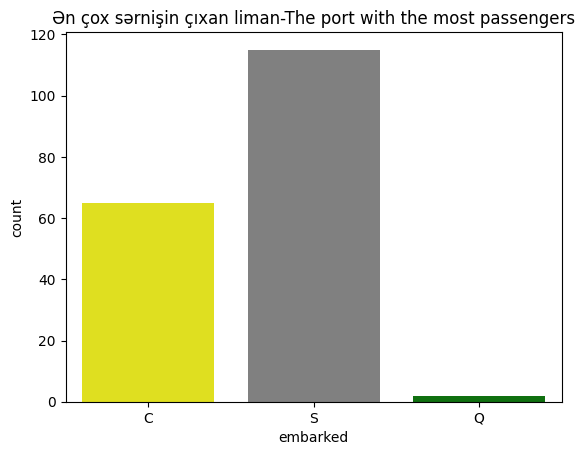

In [131]:
# counts = df['embarked'].value_counts()  #Ən çox sərnişin Southampton limanından yola düşüb,2-Cherbourg,3-Queenstown -- Most passengers departed from Southampton port,2-Cherbourg,3-Queenstown
# print(counts)

colors = ['yellow', 'grey', 'green']
sns.countplot(x='embarked', data=df, palette=colors)
plt.title("Ən çox sərnişin çıxan liman-The port with the most passengers")
plt.show()

In [82]:
alive_counts = df['alive'].value_counts() #Sağ qalanlar və ölənlərin sayı-Number of survivors and deaths
print(alive_counts)

alive
yes    125
no      59
Name: count, dtype: int64


In [95]:
average_age = df['age'].mean().round()  #Ümumi yaş ortalaması-Average age
print("Ümumi yaş ortalaması-Average age:", average_age)

Ümumi yaş ortalaması-Average age: 36.0


In [104]:
df['fare'].max() #Ən çox gediş haqqı məbləği -- Max fare

512.3292

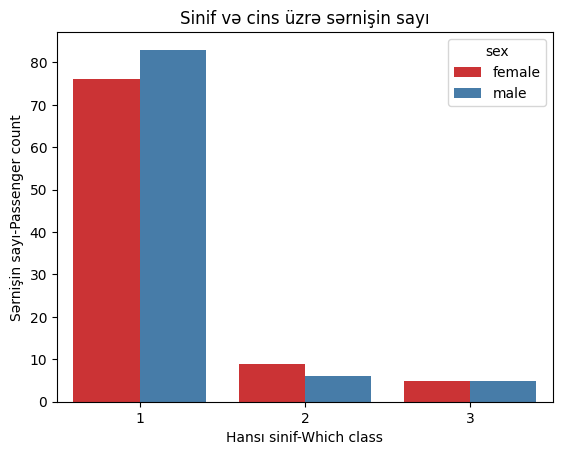

In [113]:
sns.countplot(x='pclass', hue='sex', data=df, palette='Set1')   #Number of passengers by class and gender-Sinif və cins üzrə sərnişin sayı
plt.title("Sinif və cins üzrə sərnişin sayı")
plt.ylabel("Sərnişin sayı-Passenger count")
plt.xlabel("Hansı sinif-Which class")
plt.show()

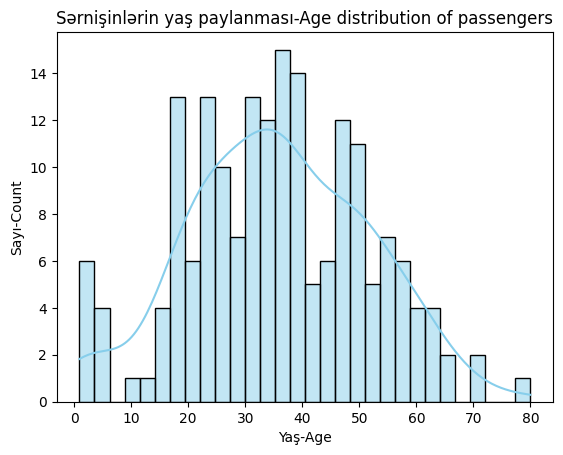

In [132]:
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')  #Age distribution of passengers
plt.title("Sərnişinlərin yaş paylanması-Age distribution of passengers")
plt.xlabel("Yaş-Age")
plt.ylabel("Sayı-Count")
plt.show()

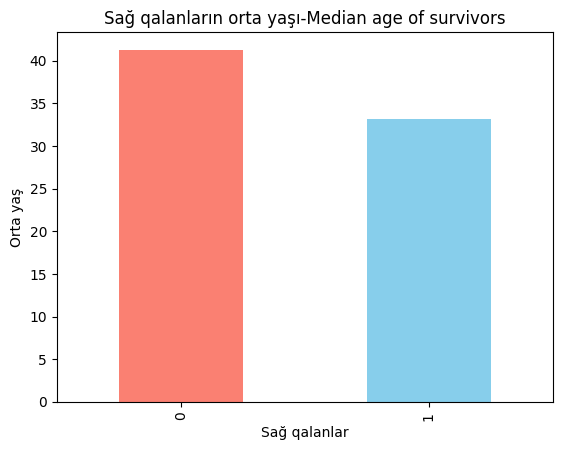

In [141]:
df.groupby('survived')['age'].mean().plot(kind='bar', color=['salmon','skyblue'])  #0-ölənlər,1-sağ qalanlar --- 0-deaths, 1-survivors
plt.title("Sağ qalanların orta yaşı-Median age of survivors")
plt.ylabel("Orta yaş")
plt.xlabel("Sağ qalanlar")
plt.show()

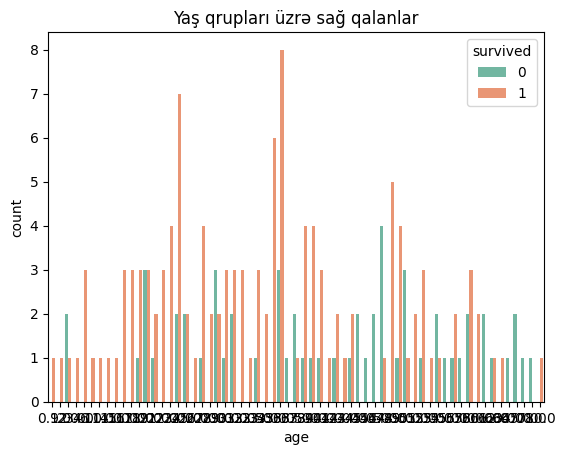

In [157]:
df['AgeGroup'] = pd.cut(df['age'], bins=[0,12,18,35,60,80], labels=['child','teen','young adult','adult','senior'])

sns.countplot(x='age', hue='survived', data=df, palette='Set2')  #Survivors by age group
plt.title("Yaş qrupları üzrə sağ qalanlar")
plt.show()

/tmp/ipython-input-42085311.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sibsp', y='survived', data=df, palette='cool')  #Ailə sayının sağ qalmağa təsiri-The effect of family size on survival


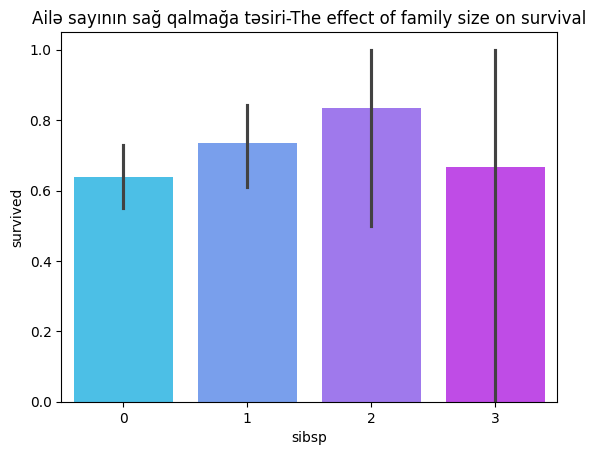

In [203]:
sns.barplot(x='sibsp', y='survived', data=df, palette='cool')  #Ailə sayının sağ qalmağa təsiri-The effect of family size on survival
plt.title("Ailə sayının sağ qalmağa təsiri-The effect of family size on survival")
plt.xlabel="survived-sağ qalanlar"
plt.ylabel="sibsp-adam sayı"
plt.show()

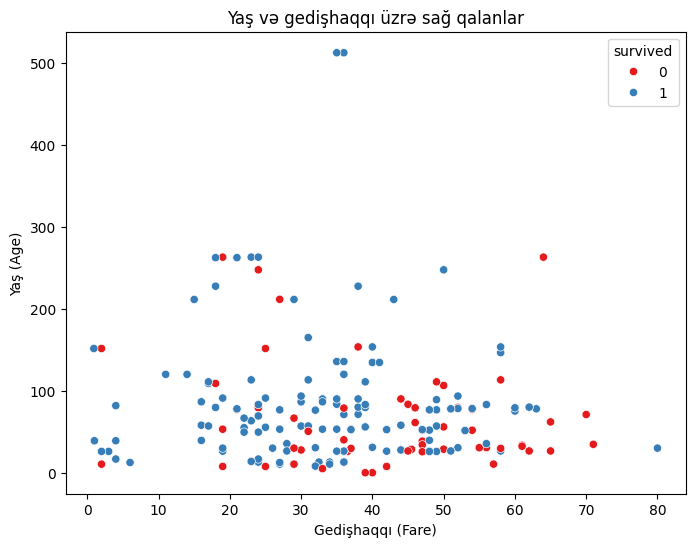

In [219]:
plt.figure(figsize=(8,6))      #Survivors by age and fare   #daha çox gedişhaqqı məbləği ödəyənlərin sağ qalma ehtimalı çoxdur
ax = sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette='Set1')
ax.set_xlabel("Gedişhaqqı (Fare)")
ax.set_ylabel("Yaş (Age)")
ax.set_title("Yaş və gedişhaqqı üzrə sağ qalanlar")
plt.show()

In [248]:
df_filtered = df.loc[df['age'] > 25]

say = df_filtered[df_filtered['survived'] == 1].groupby('sex').size()
print(say)

#Yaşı 25-dən böyük sağ qalan kişi və qadınların sayı-Number of surviving men and women over the age of 25

sex
female    54
male      30
dtype: int64


In [311]:
#Southampton-dan çıxan və fare>200 sərnişinlərin name, embark_town və fare
#Name, embark_town and fare of passengers departing from Southampton and fare>200
southampton_high_fare = df.loc[
(df['embark_town'] == 'Southampton') & (df['fare'] > 200),['name', 'embark_town', 'fare']]
print( "Southampton-dan çıxan və fare>200 sərnişinlər:")
print(southampton_high_fare)

Southampton-dan çıxan və fare>200 sərnişinlər:
                                                  name  embark_town      fare
27                      Fortune, Mr. Charles Alexander  Southampton  263.0000
88                          Fortune, Miss. Mabel Helen  Southampton  263.0000
341                     Fortune, Miss. Alice Elizabeth  Southampton  263.0000
438                                  Fortune, Mr. Mark  Southampton  263.0000
689                  Madill, Miss. Georgette Alexandra  Southampton  211.3375
730                      Allen, Miss. Elisabeth Walton  Southampton  211.3375
779  Robert, Mrs. Edward Scott (Elisabeth Walton Mc...  Southampton  211.3375
